# Détection de routes — GPSO

Pipeline : **WMS IGN → FLAIR-INC → masque routes → raster commune → publication Portal**

| Étape | Module |
|-------|--------|
| Téléchargement ortho-photos | `ortho_ign` |
| Segmentation sémantique | `flair_inference` |
| Logique métier routes | ce notebook |
| Publication Portal | `arcgis` (ESRI uniquement) |

Communes disponibles : `BOULOGNE-BILLANCOURT`, `CHAVILLE`, `ISSY-LES-MOULINEAUX`,
`MARNES-LA-COQUETTE`, `MEUDON`, `SEVRES`, `VANVES`, `VILLE-D'AVRAY`

> **Compatibilité** : Google Colab et ESRI Notebook. La publication Portal (étape 7) est disponible uniquement sur ESRI Notebook.

## 1 · Installation & modèle

In [1]:
import sys, os

# Détection environnement
IN_COLAB = "google.colab" in sys.modules or os.path.exists("/content")
IN_ESRI  = os.path.exists("/arcgis/home")

ENV_NAME = "Google Colab" if IN_COLAB else "ESRI Notebook" if IN_ESRI else "Local"
print(f"Environnement détecté : {ENV_NAME}")

Environnement détecté : Google Colab


In [2]:
import subprocess, zipfile, urllib.request, pathlib

PKGS = ["rasterio", "geopandas", "shapely", "fiona", "onnxruntime", "huggingface_hub"]

if IN_ESRI:
    subprocess.run(
        ["conda", "install", "-c", "conda-forge", "-y", "--quiet", *PKGS],
        check=True,
    )
    BASE_DIR = pathlib.Path("/arcgis/home")
else:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *PKGS], check=True)
    BASE_DIR = pathlib.Path("/content") if IN_COLAB else pathlib.Path.home() / "landcover_output"

BASE_DIR.mkdir(parents=True, exist_ok=True)

# Téléchargement de la librairie
LIB_DIR = BASE_DIR / "landcover-lib"
if not LIB_DIR.exists():
    zip_path = BASE_DIR / "landcover.zip"
    print("Téléchargement de la librairie…")
    urllib.request.urlretrieve(
        "https://github.com/DIGIT-Seine-Ouest/cv-routes-bitumees/archive/refs/heads/main.zip",
        zip_path,
    )
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(LIB_DIR)
    zip_path.unlink()

sys.path.insert(0, str(next(LIB_DIR.iterdir())))
print(f"Librairie chargée — BASE_DIR : {BASE_DIR}")

Librairie chargée — BASE_DIR : /content


## 2 · Configuration

In [3]:
from flair_inference import download_model, FlairModel

# --- À adapter ---
COMMUNE    = "VILLE-D'AVRAY"
TILES_DIR  = str(BASE_DIR / "tiles"   / COMMUNE)
EXPORT_DIR = str(BASE_DIR / "exports" / COMMUNE)
MODEL_PATH = str(BASE_DIR / "flair_12cl_resnet34_unet.onnx")

# Classes FLAIR qui définissent une "route"
ROAD_CLASSES = {1, 2}        # pervious_surface + impervious_surface
ROAD_COLOR   = (255, 140, 0)

GPSO_GEOJSON_URL = (
    "https://data.seineouest.fr/api/explore/v2.1/catalog/datasets/plu-de-gpso"
    "/exports/geojson?lang=fr&timezone=Europe%2FBerlin&epsg=2154"
)

model = FlairModel(download_model(dest=MODEL_PATH))
print(f"Modèle prêt — {model.NUM_CLASSES} classes FLAIR")

Modèle déjà présent : /content/flair_12cl_resnet34_unet.onnx
Modèle prêt — 12 classes FLAIR


## 3 · Téléchargement des tuiles WMS

In [4]:
from ortho_ign import fetch_city_tiles

def progress(r, m):
    print(f"\r  {'█' * int(r * 30) + '░' * (30 - int(r * 30))}  {m}", end="", flush=True)

tiles = fetch_city_tiles(
    commune_name=COMMUNE,
    tiles_dir=TILES_DIR,
    geojson_url=GPSO_GEOJSON_URL,
    on_progress=progress,
)
print(f"\n{len(tiles)} tuile(s) prête(s)")

  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░  Bloc 1/15 — VILLE-D'AVRAY…

/usr/local/lib/python3.12/dist-packages/rasterio/io.py:140: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  rd = DatasetReader(mempath, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


  ██████████████████████████████  777 tuiles prêtes — VILLE-D'AVRAY
777 tuile(s) prête(s)


## 4 · Inférence FLAIR

In [5]:
import numpy as np
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from flair_inference import mask_from_classes, colorize, apply_overlay, class_stats
from ortho_ign import load_tile_as_rgb
from PIL import Image

# Colab (12 GB RAM) : 4 workers → 4 × ~300 MB ≈ 1.2 GB modèles en mémoire
# ESRI : auto-détection CPU
N_WORKERS = 4 if IN_COLAB else min(os.cpu_count() or 4, 8)
print(f"Inférence parallèle — {N_WORKERS} workers")

# Un FlairModel (InferenceSession ONNX) par thread — non thread-safe si partagé
_thread_local = threading.local()

def _get_model():
    if not hasattr(_thread_local, "model"):
        _thread_local.model = FlairModel(MODEL_PATH)
    return _thread_local.model

_lock = threading.Lock()
_done = [0]

def _process_tile(args):
    idx, tile_path = args
    m         = _get_model()
    img       = load_tile_as_rgb(tile_path)
    arr255    = np.transpose(np.array(img, dtype=np.float32), (2, 0, 1))
    class_map = m.predict(arr255)
    road_mask = mask_from_classes(class_map, ROAD_CLASSES)
    stats     = class_stats(class_map, target_ids=ROAD_CLASSES)
    with _lock:
        _done[0] += 1
        progress(_done[0] / len(tiles), f"Tuile {_done[0]}/{len(tiles)}")
    return {
        "tile_path":    tile_path,
        "ortho":        img,
        "flair_map":    Image.fromarray(colorize(class_map)),
        "road_overlay": apply_overlay(img, road_mask, ROAD_COLOR),
        "road_mask":    road_mask,
        "road_pct":     stats["target_pct"],
    }

results = [None] * len(tiles)
with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
    futures = {executor.submit(_process_tile, (i, p)): i for i, p in enumerate(tiles)}
    for future in as_completed(futures):
        results[futures[future]] = future.result()

avg_road = sum(r["road_pct"] for r in results) / len(results)
print(f"\n{len(results)} tuiles — surface route moyenne : {avg_road:.1f}%")

Inférence parallèle — 4 workers
  ██████████████████████████████  Tuile 777/777
777 tuiles — surface route moyenne : 9.8%


## 5 · Visualisation rapide

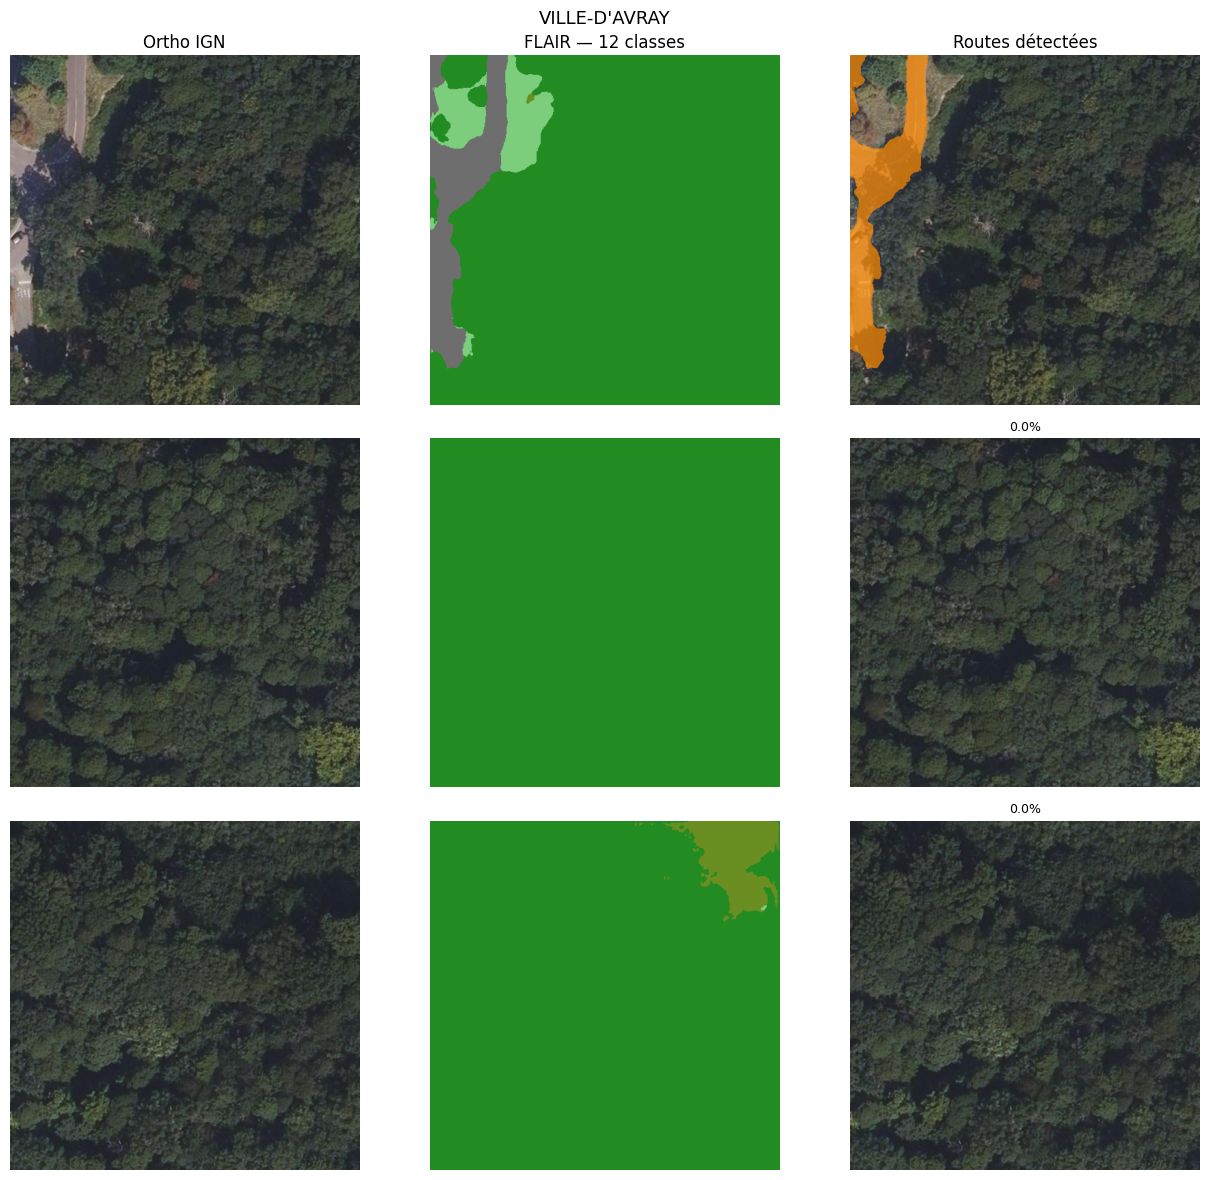

In [6]:
import matplotlib.pyplot as plt

n = min(3, len(results))
fig, axes = plt.subplots(n, 3, figsize=(13, 4 * n))
if n == 1: axes = [axes]

for i, r in enumerate(results[:n]):
    axes[i][0].imshow(r["ortho"])
    axes[i][1].imshow(r["flair_map"])
    axes[i][2].imshow(r["road_overlay"])
    axes[i][2].set_title(f"{r['road_pct']:.1f}%", fontsize=9)
    for ax in axes[i]: ax.axis("off")

axes[0][0].set_title("Ortho IGN")
axes[0][1].set_title("FLAIR — 12 classes")
axes[0][2].set_title("Routes détectées")
plt.suptitle(COMMUNE, fontsize=13)
plt.tight_layout()
plt.show()

## 6 · Création du raster commune

On fusionne les masques de toutes les tuiles en **un seul GeoTIFF** couvrant la commune entière (EPSG:2154).
C'est ce fichier qui sera publié sur le Portal.

In [7]:
import os
import rasterio
from rasterio.merge import merge as rio_merge
from ortho_ign import mask_to_geotiff

os.makedirs(EXPORT_DIR, exist_ok=True)
tif_dir = os.path.join(EXPORT_DIR, "tuiles")
os.makedirs(tif_dir, exist_ok=True)

# 1. Masque par tuile
tif_paths = []
for r in results:
    tile_name = os.path.splitext(os.path.basename(r["tile_path"]))[0]
    tif_paths.append(mask_to_geotiff(
        r["road_mask"], r["tile_path"],
        os.path.join(tif_dir, f"{tile_name}_routes.tif"),
    ))

# 2. Fusion → raster commune entière (un seul GeoTIFF, pas de gaps)
MERGED_TIF = os.path.join(EXPORT_DIR, f"{COMMUNE.lower()}_routes.tif")
sources = [rasterio.open(p) for p in tif_paths]
mosaic, transform = rio_merge(sources)
meta = sources[0].meta.copy()
meta.update(count=1, width=mosaic.shape[2], height=mosaic.shape[1],
            transform=transform, compress="lzw", nodata=255)
for src in sources:
    src.close()
with rasterio.open(MERGED_TIF, "w", **meta) as dst:
    dst.write(mosaic[0:1])

print(f"Raster : {MERGED_TIF}  ({os.path.getsize(MERGED_TIF)/1e6:.1f} MB)")
print(f"CRS    : {meta['crs']}  |  {meta['width']}×{meta['height']} px")

Raster : /content/exports/VILLE-D'AVRAY/ville-d'avray_routes.tif  (3.7 MB)
CRS    : EPSG:2154  |  18964×10404 px
